Name: Papadopoulos Ioannis-Rafail
AEM: 10696

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


In [ ]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical


In [ ]:
train_df = pd.read_csv("datasetTV.csv", header=None)

print("Dataset shape:", train_df.shape)
train_df.head()


Dataset shape: (8743, 225)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224
0,0.312530,-0.23940,-0.007568,0.526180,-0.090250,-0.26424,1.26620,0.057444,-0.23387,-0.428440,-0.035133,0.213050,-0.009092,-0.469230,0.059560,-0.11531,-0.084137,1.875600,-0.063369,-0.033381,0.27896,1.19740,0.76456,-0.084410,-0.27622,0.81994,0.18004,0.264390,0.600290,0.83972,-0.35337,0.009995,0.15135,-0.238820,-0.42852,-0.384640,0.14970,1.07410,-0.13173,-0.42061,-0.002615,0.27083,0.11447,-0.173590,0.550130,0.77626,0.517550,0.20729,0.14401,0.404420,0.155600,-1.055400,-0.170220,-0.181180,-0.32163,-0.13804,-0.10341,-0.309110,0.10210,0.66978,-0.172810,0.118590,0.51417,1.608800,0.20415,0.017020,0.769180,1.512900,0.601020,1.46530,-0.072149,0.211080,0.18834,0.168390,-0.194270,-0.007654,0.417340,0.27391,-0.11748,0.55364,0.39987,-0.27408,-0.27013,0.114260,0.26008,1.020300,-0.221050,1.17940,-0.054008,-0.202910,0.34397,0.11364,-0.346660,0.89262,1.486600,-0.092223,-0.048209,-0.652880,-0.013075,-0.001465,0.78410,0.13523,-0.066256,0.007814,0.027596,0.002223,-0.717450,0.59112,-0.216270,0.096212,0.026658,1.12530,-0.675030,0.961680,1.060200,-0.088841,0.32422,0.080492,0.698550,0.28709,0.290820,0.209030,0.12631,-0.019863,-0.00833,-0.15180,0.26181,0.72265,-0.17166,0.645500,0.700720,-0.069245,0.27110,-0.051920,1.06210,0.48480,0.213170,0.17016,0.66931,0.850890,-0.004043,-0.446830,0.68470,-0.155940,0.349090,1.113300,-0.043636,0.30592,-0.22661,-0.19241,-0.362320,0.039463,-0.851300,-0.356110,0.164270,0.949210,-0.49776,0.342320,-0.20674,-0.050935,-0.000207,-0.47595,-0.08386,0.30918,0.482370,-0.494920,0.136940,0.509140,0.302890,0.61588,0.917680,1.09700,-0.400260,0.088854,0.11610,1.11330,0.546960,0.273750,0.037758,-0.08181,0.07680,0.400930,0.76439,-0.16658,-0.131880,0.320480,-0.624210,0.092815,-0.539550,0.19519,-0.75666,0.686760,-0.264000,-0.036587,-0.229700,0.404880,-0.037858,0.747710,0.394650,0.01727,0.012745,0.136490,0.046462,0.52695,-0.331570,0.173690,-0.177690,0.769650,0.10292,-0.087702,0.119980,-0.10138,1.28330,-0.381270,0.200440,-0.54450,0.927700,-0.051764,-0.088081,-0.135800,1.188800,0.590240,0.13113,0.940970,1
1,-0.180790,0.43987,-0.146410,0.589490,-0.571440,1.31360,0.47487,0.018913,0.51212,-0.147690,-0.354890,-0.171200,-0.212370,1.229000,0.084167,-0.30266,0.511120,0.098169,-0.040029,0.630740,1.02150,0.68190,-0.26062,0.059432,-0.25691,1.23180,0.29465,-0.058659,-0.406910,-0.14193,0.03779,0.796720,0.57587,0.125810,1.11760,0.115580,0.64171,-0.23701,0.12760,0.29760,-0.267210,0.34955,-0.49535,0.326480,0.576470,0.44597,-0.528150,-0.63701,1.35640,-0.020595,-0.196820,-0.106810,-0.057108,0.093622,0.47493,0.67839,0.27704,0.124510,-0.75383,0.23150,0.207590,0.747960,0.10487,0.559390,0.61464,0.503820,0.106910,1.035200,0.058031,1.11820,1.094200,-0.195820,0.70510,0.006189,0.044197,0.460750,0.886460,0.29911,0.32803,0.15224,-0.23455,0.35576,0.22533,0.046015,-0.13694,-0.027173,0.028578,-0.35257,0.836470,-0.019013,-0.58575,-0.17166,0.885910,-0.56857,-0.371170,0.869210,0.491030,-0.178110,0.283670,-0.254710,0.80182,-0.31794,0.053056,0.157190,0.137920,0.064513,-0.244580,1.48710,-0.186960,-0.257610,-0.257040,0.26198,-0.051414,0.441770,-0.258990,0.858570,-0.33418,0.112360,-0.497680,0.19422,-0.631650,0.019803,0.42258,-0.401500,0.89294,-0.26998,0.26488,1.36120,-0.13643,0.011946,0.513240,0.172570,

In [ ]:
X = train_df.iloc[:, :-1]
y = train_df.iloc[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (8743, 224)
y shape: (8743,)


In [ ]:
y.value_counts().sort_index()


,count
224,
1,1769
2,1720
3,1754
4,1716
5,1784


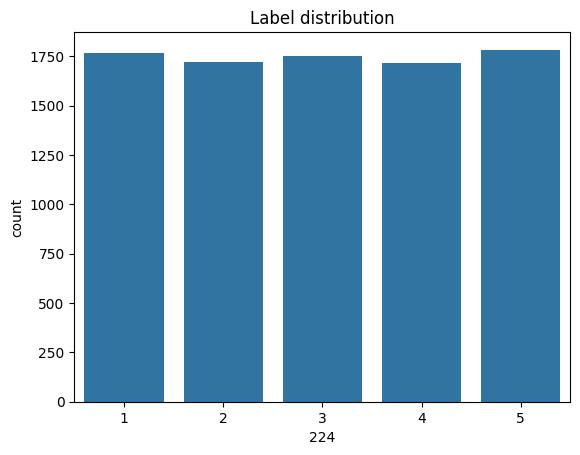

In [ ]:
sns.countplot(x=y)
plt.title("Label distribution")
plt.show()


In [ ]:
print("NaN values per column (non-zero only):")
X.isna().sum()[X.isna().sum() > 0]


NaN values per column (non-zero only):


,0


In [ ]:
X.isna().sum().sum()


np.int64(0)

In [ ]:
X.describe().T[['mean', 'std', 'min', 'max']]


,mean,std,min,max
0,0.360086,0.545784,-1.05290,2.0350
1,0.001636,0.321264,-1.49200,1.5822
2,0.343860,0.537970,-1.16850,2.0754
3,0.177411,0.479141,-1.15490,1.9280
4,0.199805,0.469726,-1.23880,1.9342
...,...,...,...,...
219,0.099152,0.422491,-1.24760,2.2036
220,0.589612,0.557340,-0.99605,2.3118
221,0.293870,0.526766,-1.19950,2.3068
222,0.505508,0.566306,-1.12850,2.1061


In [ ]:
zero_variance_features = X.columns[X.std() == 0]
len(zero_variance_features)


0

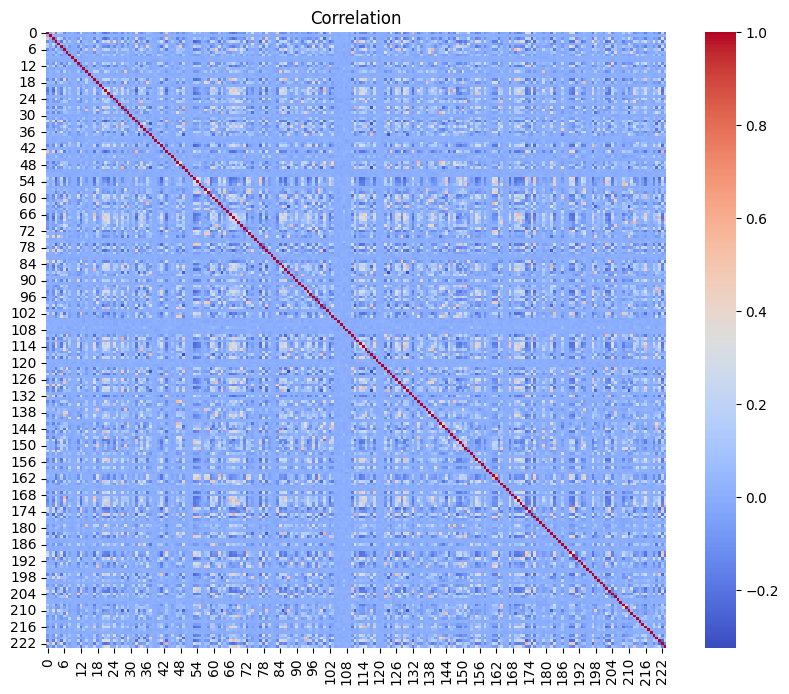

In [ ]:
sample_features = X.iloc[:, :224]
plt.figure(figsize=(10, 8))
sns.heatmap(sample_features.corr(), cmap="coolwarm")
plt.title("Correlation")
plt.show()


Since all stuff seem 'alright' we wont need specific data cleaning

Techniques like KNN are way too slow with so many data, although they provide good enough results (as we said in the theory compared to Bayes)


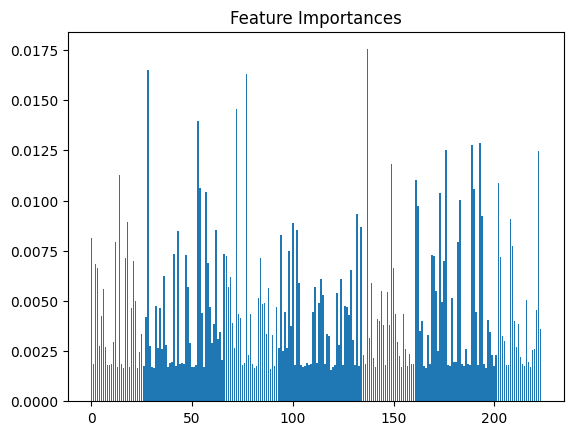

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
importances = rf.feature_importances_
plt.bar(range(len(importances)), importances)
plt.title("Feature Importances")
plt.show()


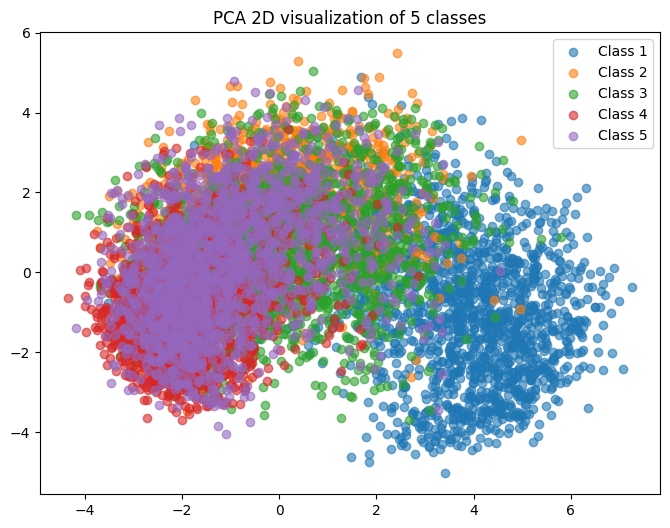

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

plt.figure(figsize=(8,6))
for label in sorted(y.unique()):
    plt.scatter(X_2d[y==label,0], X_2d[y==label,1], label=f"Class {label}", alpha=0.6)
plt.legend()
plt.title("PCA 2D visualization of 5 classes")
plt.show()


------------------------------------------------------

Tried different MLPs but the following performed 'better'

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Original number of features:", X.shape[1])
print("Number of PCA components to retain 95% variance:", pca.n_components_)


Original number of features: 224
Number of PCA components to retain 95% variance: 190


We saw how many components we needed for 95 var but now lets do it into our data before inputing them

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X_scaled)

y_cat = to_categorical(y-1, num_classes=5)


In [ ]:
def build_mlp(input_dim):
    model = Sequential([
        Dense(256, activation='relu', input_dim=input_dim),
        BatchNormalization(),
        Dropout(0.4),

        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        Dense(5, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model


In [ ]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_pca)):
    print(f"Fold {fold+1}")

    X_train, X_val = X_pca[train_idx], X_pca[val_idx]
    y_train, y_val = y_cat[train_idx], y_cat[val_idx]

    model = build_mlp(X_pca.shape[1])

    es = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    )

    history = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=200,
        batch_size=64,
        callbacks=[es],
        verbose=0
    )

    loss, acc = model.evaluate(X_val, y_val, verbose=0)
    scores.append(acc)
    print("Accuracy:", acc)

print("5-fold CV accuracy:", np.mean(scores), "±", np.std(scores))


Fold 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Accuracy: 0.8461978435516357
Fold 2
Accuracy: 0.8421955108642578
Fold 3
Accuracy: 0.8427672982215881
Fold 4
Accuracy: 0.8329519629478455
Fold 5
Accuracy: 0.8426773548126221
5-fold CV accuracy: 0.8413579940795899 ± 0.004438778831458945


In [ ]:
final_model = build_mlp(X_pca.shape[1])

from tensorflow.keras.callbacks import EarlyStopping

es_final = EarlyStopping(
    monitor='loss',
    patience=10,
    restore_best_weights=True
)

# train on whole training set
final_model.fit(
    X_pca, y_cat,
    epochs=200,
    batch_size=64,
    callbacks=[es_final],
    verbose=1
)
X_test = pd.read_csv("datasetTest.csv", header=None).values
X_test_scaled = scaler.transform(X_test)  #transform our test data
X_test_pca = pca.transform(X_test_scaled)

predictions = final_model.predict(X_test_pca)  #and test on trained model
labelsX = np.argmax(predictions, axis=1) + 1  # 0...4--->1....5

np.save("labelsX.npy", labelsX)
print("Predictions saved to labelsX.npy")


Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


137/137 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.4748 - loss: 1.3474
Epoch 2/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7430 - loss: 0.6500
Epoch 3/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7820 - loss: 0.5507
Epoch 4/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8114 - loss: 0.4721
Epoch 5/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8336 - loss: 0.4264
Epoch 6/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8521 - loss: 0.3788
Epoch 7/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8617 - loss: 0.3391
Epoch 8/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8768 - loss: 0.3180
Epoch 9/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8817 - loss: 0.2931
Epoch 10/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8859 - loss: 0.2840
Epoch 11/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8967 - loss: 0.2582
Epoch 12/200
137/137 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/ste

In [ ]:
# Checking if labelsX can load
labelsX = np.load("labelsX.npy")

# Checking if the labels have the required values range
print("Min label:", labelsX.min())
print("Max label:", labelsX.max())
print("Size:", labelsX.size)

#check some balance (does not mean its fine but at least we can exclude that for some 'mistake' we put all the samples in one label for example)
(unique, counts) = np.unique(labelsX, return_counts=True)
print("Class distribution:")
for a, b in zip(unique, counts):
    print(f"Class {a}: {b} samples")


Min label: 1
Max label: 5
Size: 6955
Class distribution:
Class 1: 1427 samples
Class 2: 1322 samples
Class 3: 1439 samples
Class 4: 1307 samples
Class 5: 1460 samples


In [ ]:
labels_loaded = np.load("labelsX.npy")
print("Shape after loading:", labels_loaded.shape)


Shape after loading: (6955,)
